In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [4]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR    = CONFIGS['filepaths']['splits']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
PREDSDIR     = CONFIGS['filepaths']['predictions']
RAWDIR       = CONFIGS['filepaths']['raw']
MODELS       = CONFIGS['experiments']
LATRANGE     = CONFIGS['domain']['latrange']
LONRANGE     = CONFIGS['domain']['lonrange']
FIELDVARS    = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NNSEEDS      = MODELS['nn']['seeds']
OPTIMIZEDEQS = MODELS['sr']['optimizedeqs']
ORDER        = ['sr_med','sr_hi','nn_gauss']
SPLIT        = 'test'
NBINS        = 20
MINSAMPLES   = 50
SRFUNCTIONS  = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'max':np.maximum,'min':np.minimum}
COLORS = {}
LABELS = {}
for name,config in {**MODELS['nn']['runs'],**OPTIMIZEDEQS}.items():
    COLORS[name] = config['color']
    LABELS[name] = config['description']
KWMAP = dict(coast=True,latlim=LATRANGE,lonlim=LONRANGE,latlines=[10,15,20],lonlines=[65,75,85],grid=False)

In [ ]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None: w = w*mask[:,None,:]
    return w.sum(axis=2)

def to_phys(norm):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(norm,dtype=float)))

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS); ns.update(variables); ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

def r2(obs,pred):
    mask = np.isfinite(obs)&np.isfinite(pred)
    o,p = obs[mask],pred[mask]
    return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def bin_1d(x,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite = np.isfinite(x)&np.isfinite(z)
    x,z = x[finite],z[finite]
    edges = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    n = len(edges)-1
    xi = np.clip(np.digitize(x,edges)-1,0,n-1)
    counts = np.bincount(xi,minlength=n)
    sums   = np.bincount(xi,weights=z,minlength=n)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

def bin_2d(x,y,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z = x[finite],y[finite],z[finite]
    xedges = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    yedges = np.linspace(*np.percentile(y,[plo,phi]),nbins+1)
    xi = np.clip(np.digitize(x,xedges)-1,0,nbins-1)
    yi = np.clip(np.digitize(y,yedges)-1,0,nbins-1)
    idx = xi*nbins+yi
    counts = np.bincount(idx,minlength=nbins*nbins).reshape(nbins,nbins)
    sums   = np.bincount(idx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    return (0.5*(xedges[:-1]+xedges[1:]),0.5*(yedges[:-1]+yedges[1:]),
            np.where(counts>=minsamples,sums/counts,np.nan),counts)

def flatten(da):
    if 'time' in da.dims: return da.transpose('time','lat','lon').values.ravel()
    return np.tile(da.values,(ntime,1,1)).ravel()

def to_map(flat):
    return np.nanmean(flat.reshape(ntime,nlat,nlon),axis=0)

def load_pred(name,split=SPLIT):
    path = os.path.join(PREDSDIR,f'{name}_{split}_predictions.nc')
    if not os.path.exists(path): return None
    with xr.open_dataset(path) as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims: da = da.mean('seed')
    if 'complexity' in da.dims: da = da.isel(complexity=0)
    da = da.reindex(lat=lat,lon=lon,method='nearest')
    return da.transpose('time','lat','lon').values.ravel()

def plot1d(predictors):
    pdata  = [(FEATURES[p][0][valid],FEATURES[p][1]) for p in predictors]
    binned = [bin_1d(x,obsflat[valid]) for x,_ in pdata]
    maxcnt = max(c.max() for _,_,c in binned)
    ncols  = min(3,len(predictors)); nrows = -(-len(predictors)//ncols)
    names  = [n for n in ORDER if n in MODELPRED]
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=1.5,sharex=False,sharey=True)
    axsf    = np.atleast_1d(axs).ravel()
    for i,(ax,p,(x,label),(xc,obsbin,counts)) in enumerate(zip(axsf,predictors,pdata,binned)):
        col = i%ncols
        dax = ax.twinx()
        dax.bar(xc,counts,width=xc[1]-xc[0],absolute_width=True,edgecolor='none',
                color='gray5',alpha=0.3)
        dax.format(ylim=(0,1.5*maxcnt),yformatter='sci')
        if col==ncols-1 or i==len(predictors)-1:
            dax.format(ylabel='Sample Count')
        else:
            dax.tick_params(axis='y',labelright=False)
        ax.plot(xc,obsbin,color='k',linewidth=2,zorder=5)
        for name in names:
            _,predbin,_ = bin_1d(x,MODELPRED[name][valid])
            ax.plot(xc,predbin,color=COLORS[name],linewidth=1.5,zorder=5)
        ax.format(grid=False,xlabel=label)
    for ax in axsf[len(predictors):]: ax.set_visible(False)
    axsf[0].format(ylabel='Total Precipitation (mm)')
    handles  = [Line2D([],[],color='k',linewidth=2,label='Observed')]
    handles += [Line2D([],[],color=COLORS[n],linewidth=1.5,label=LABELS[n]) for n in names]
    fig.legend(handles,loc='b',ncols=len(handles))
    return fig

def plot2d(px,py):
    x,xl = FEATURES[px][0][valid],FEATURES[px][1]
    y,yl = FEATURES[py][0][valid],FEATURES[py][1]
    names   = [n for n in ORDER if n in MODELPRED]
    xc,yc,obsbin,obsc = bin_2d(x,y,obsflat[valid])
    panels  = ['obs']+names
    fig,axs = pplt.subplots(nrows=1,ncols=len(panels),refwidth=1.5,share=True)
    axsf    = np.atleast_1d(axs).ravel()
    for ax,panel in zip(axsf,panels):
        if panel=='obs':
            zb = obsbin; cmap,vmin,vmax,extend = 'Blues',0,3,'max'
        else:
            _,_,predbin,_ = bin_2d(x,y,MODELPRED[panel][valid])
            zb = predbin-obsbin; cmap,vmin,vmax,extend = 'DryWet',-2,2,'both'
        m = ax.pcolormesh(xc,yc,zb.T,cmap=cmap,vmin=vmin,vmax=vmax,levels=21,extend=extend)
        ax.contour(xc,yc,obsc.T,color='red3',linewidth=0.5)
        ax.format(title='Observed' if panel=='obs' else LABELS[panel],
                  xlabel=xl,grid=False)
    axsf[0].format(ylabel=yl)
    fig.colorbar(m,loc='r',label='Model − Observed (mm)' if names else 'Total Precipitation (mm)')
    return fig

In [ ]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    stats = json.load(f)
tpmean = float(stats['tp_mean'])
tpstd  = float(stats['tp_std'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = ds.sizes['time'],ds.sizes['lat'],ds.sizes['lon']
    nsig = ds.sizes.get('sig',1)
    lat  = ds['lat'].values; lon = ds['lon'].values; dsig = ds['dsig'].values
    fields   = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None)
    blnorm  = flatten(ds['bl'])
    lfnorm  = flatten(ds['lf'])
    shfnorm = flatten(ds['shf'])
    lhfnorm = flatten(ds['lhf'])

kernels = []
for seed in NNSEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as ds:
            kernels.append(ds['k'].values)
ki = (np.mean([kernel_integrate(fields,k,dsig,surfmask) for k in kernels],axis=0)
      if kernels else fields.mean(axis=2))
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()
    lf  = flatten(ds['lf']); shf = flatten(ds['shf']); lhf = flatten(ds['lhf'])
    sdo = flatten(ds['sdo']) if 'sdo' in ds else None
    sef = flatten(ds['sef']) if 'sef' in ds else None
    months = np.tile(ds.time.dt.month.values[:,None,None]*np.ones((1,nlat,nlon)),1).ravel().astype(int)

semap = None
sepath = os.path.join(RAWDIR,'ERA5_surface_elevation.nc')
if os.path.exists(sepath):
    with xr.open_dataset(sepath,engine='netcdf4') as ds:
        sevar = list(ds.data_vars)[0]
        se = ds[sevar]
        if 'time' in se.dims: se = se.isel(time=0)
        se    = se.interp(lat=lat,lon=lon,method='linear')
        semap = se.values.astype(np.float32)
seflat = np.tile(semap,(ntime,1,1)).ravel() if semap is not None else None
sdomap = sdo.reshape(ntime,nlat,nlon)[0] if sdo is not None else None

regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath,'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

SRVARS = {'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,
          'bl':blnorm,'lf':lfnorm,'shf':shfnorm,'lhf':lhfnorm}

MODELPRED = {}
for name,config in OPTIMIZEDEQS.items():
    entry     = SR_REGISTRY.get(name,{})
    form      = entry.get('form',config['form'])
    constants = entry.get('constants',config['init'])
    pnames    = used_predictors(form,SRVARS.keys())
    if all(p in SRVARS for p in pnames):
        MODELPRED[name] = to_phys(eval_form(form,{p:SRVARS[p] for p in pnames},constants))

for name in MODELS['nn']['runs']:
    pred = load_pred(name)
    if pred is not None:
        MODELPRED[name] = pred

valid = np.isfinite(obsflat)
for arr in SRVARS.values(): valid &= np.isfinite(arr)

FEATURES = {
    'rh':         (rhk,         r'$\widehat{\mathrm{RH}}$'),
    'thetae':     (thetaek,     r'$\widehat{\theta_e}$'),
    'thetaestar': (thetaestark, r'$\widehat{\theta_e^*}$'),
    'bl':         (blnorm,      r'$B_L$ (m/s$^2$)'),
    'lf':         (lf,          'LF (0–1)'),
    'shf':        (shf,         r'SHF (W m$^{-2}$)'),
    'lhf':        (lhf,         r'LHF (W m$^{-2}$)')}
if sdo is not None: FEATURES['sdo'] = (sdo,'SDO (m)')
if sef is not None: FEATURES['sef'] = (sef,'SEF (m)')

print(f'Valid: {valid.sum():,} | Loaded: {sorted(MODELPRED.keys())}')
for name in ORDER:
    if name in MODELPRED:
        print(f'  {LABELS.get(name,name):20s}  R²={r2(obsflat[valid],MODELPRED[name][valid]):.3f}')
    else:
        print(f'  {LABELS.get(name,name):20s}  — not available')

In [ ]:
names = [name for name in ORDER if name in MODELPRED]
obs   = obsflat[valid]
mons  = months[valid]
lfv   = lf[valid]
latv  = np.tile(lat[None,:,None],(ntime,1,nlon)).ravel()[valid]
lonv  = np.tile(lon[None,None,:],(ntime,nlat,1)).ravel()[valid]

regions = {'Ocean':lfv<0.1,'Land':lfv>0.9,
           '5–15°N':(latv>=5)&(latv<15),'15–25°N':(latv>=15)&(latv<=25),
           '60–75°E':(lonv>=60)&(lonv<75),'75–90°E':(lonv>=75)&(lonv<=90)}

R2 = {}
for name in names:
    pred = MODELPRED[name][valid]
    R2[name] = {'overall': r2(obs, pred)}
    for m in [6,7,8]:
        R2[name][m] = r2(obs[mons==m], pred[mons==m])
    for rn,mask in regions.items():
        R2[name][rn] = r2(obs[mask], pred[mask])

clrs = [COLORS[n] for n in names]
fig,axs = pplt.subplots(nrows=1,ncols=3,refwidth=2.8,refheight=2,sharex=False,spany=True)
axs.format(ylabel=r'$R^2$',ylim=(0,0.6),yticks=0.1)

axs[0].bar(np.arange(len(names)),[R2[n]['overall'] for n in names],color=clrs,alpha=0.85)
axs[0].format(xticks=np.arange(len(names)),xticklabels=[LABELS[n] for n in names],
              xrotation=15,title=r'Overall $R^2$',grid=False)

xmon = [6,7,8]
for name in names:
    axs[1].plot(xmon,[R2[name][m] for m in xmon],color=COLORS[name],
                linewidth=1.5,marker='o',markersize=4,label=LABELS[name])
axs[1].format(xticks=xmon,xticklabels=['Jun','Jul','Aug'],title=r'$R^2$ by Month',grid=False)
axs[1].legend(loc='b',ncols=len(names))

xreg  = np.arange(len(regions))
width = 0.8/max(len(names),1)
for i,name in enumerate(names):
    offset = (i-(len(names)-1)/2)*width
    axs[2].bar(xreg+offset,[R2[name][rn] for rn in regions],
               width=width,color=COLORS[name],alpha=0.85)
axs[2].format(xticks=xreg,xticklabels=list(regions.keys()),xrotation=20,
              title=r'$R^2$ by Region',grid=False)
pplt.show()

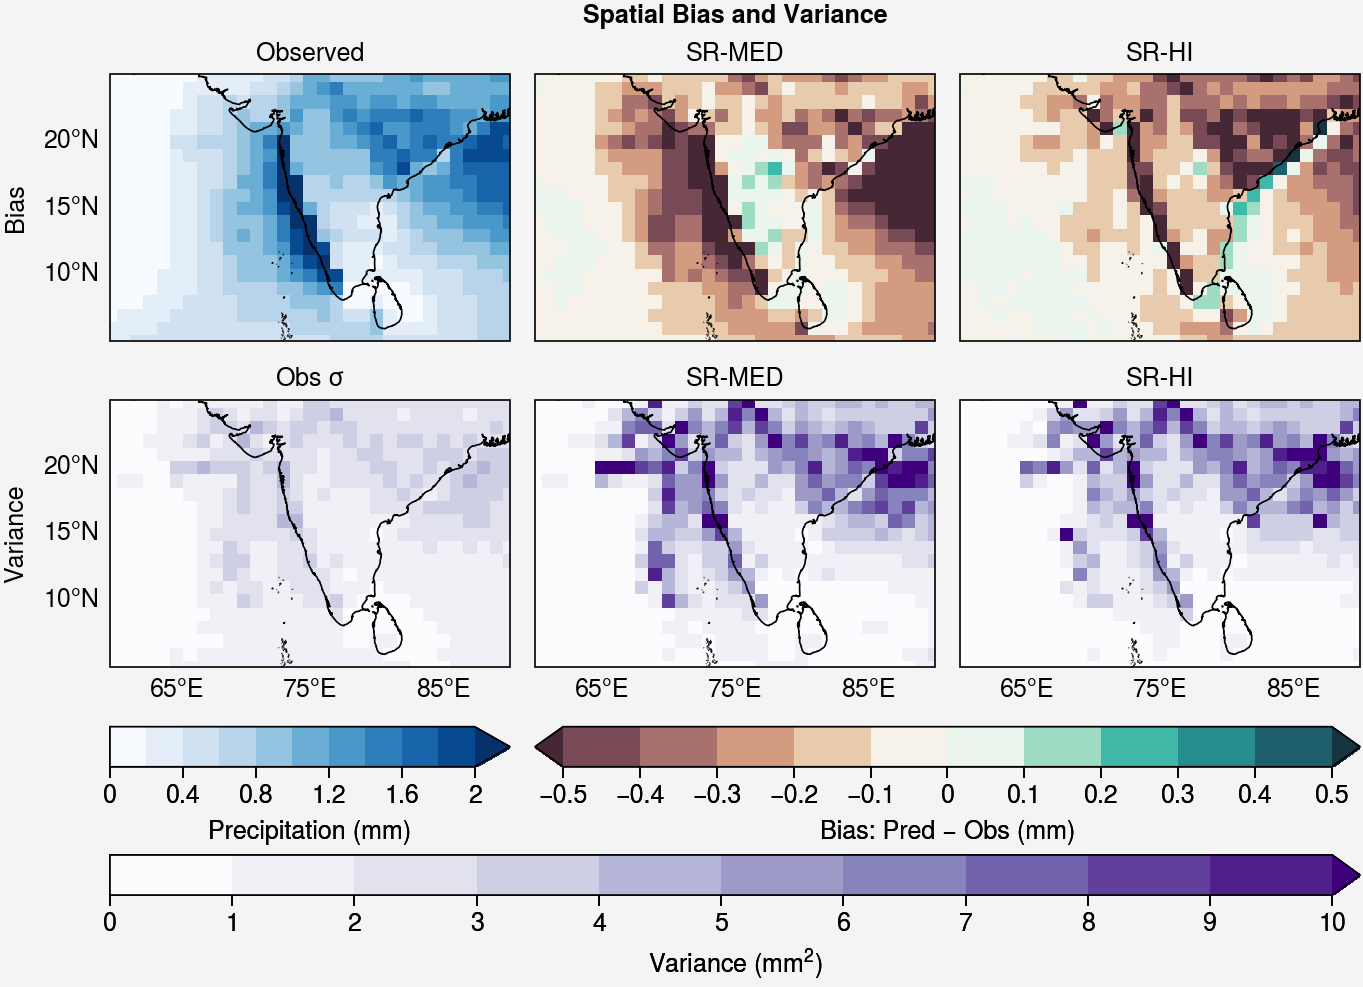

In [8]:
obsmap = to_map(obsflat)
obs3d  = obsflat.reshape(ntime,nlat,nlon)
names  = [n for n in ORDER if n in MODELPRED]
ncols  = 1+len(names)

fig,axs = pplt.subplots(nrows=2,ncols=ncols,proj='cyl',refwidth=2,share=False)

mc = axs[0,0].pcolormesh(lon,lat,obsmap,cmap='Blues',vmin=0,vmax=2,extend='max')
axs[0,0].format(title='Observed',latlabels='l',lonlabels=False,**KWMAP)

mb = None
for i,name in enumerate(names):
    bmap = to_map(MODELPRED[name])-obsmap
    mb = axs[0,i+1].pcolormesh(lon,lat,bmap,cmap='DryWet',vmin=-0.5,vmax=0.5,extend='both')
    axs[0,i+1].format(title=LABELS.get(name,name),latlabels=False,lonlabels=False,**KWMAP)

var_maps = []
vmax_var = 0
for name in names:
    pred3d = MODELPRED[name].reshape(ntime,nlat,nlon)
    bmean  = np.nanmean(pred3d-obs3d,axis=0)
    vmap   = np.nanmean((pred3d-obs3d)**2,axis=0)-bmean**2
    var_maps.append(vmap)
    vmax_var = max(vmax_var,float(np.nanpercentile(vmap,98)))

obs_std = np.nanstd(obs3d,axis=0)
axs[1,0].pcolormesh(lon,lat,obs_std,cmap='Purples',vmin=0,vmax=vmax_var,extend='max')
axs[1,0].format(title=r'Obs $\sigma$',latlabels='l',lonlabels='b',**KWMAP)

mv = None
for i,(name,vmap) in enumerate(zip(names,var_maps)):
    mv = axs[1,i+1].pcolormesh(lon,lat,vmap,cmap='Purples',vmin=0,vmax=vmax_var,extend='max')
    axs[1,i+1].format(title=LABELS.get(name,name),latlabels=False,lonlabels='b',**KWMAP)

fig.colorbar(mc,loc='b',col=1,label='Precipitation (mm)')
if mb: fig.colorbar(mb,loc='b',col=(2,ncols),label='Bias: Pred − Obs (mm)')
if mv: fig.colorbar(mv,loc='b',label=r'Variance (mm$^2$)')
fig.format(suptitle='Spatial Bias and Variance',rowlabels=['Bias','Variance'])
pplt.show()

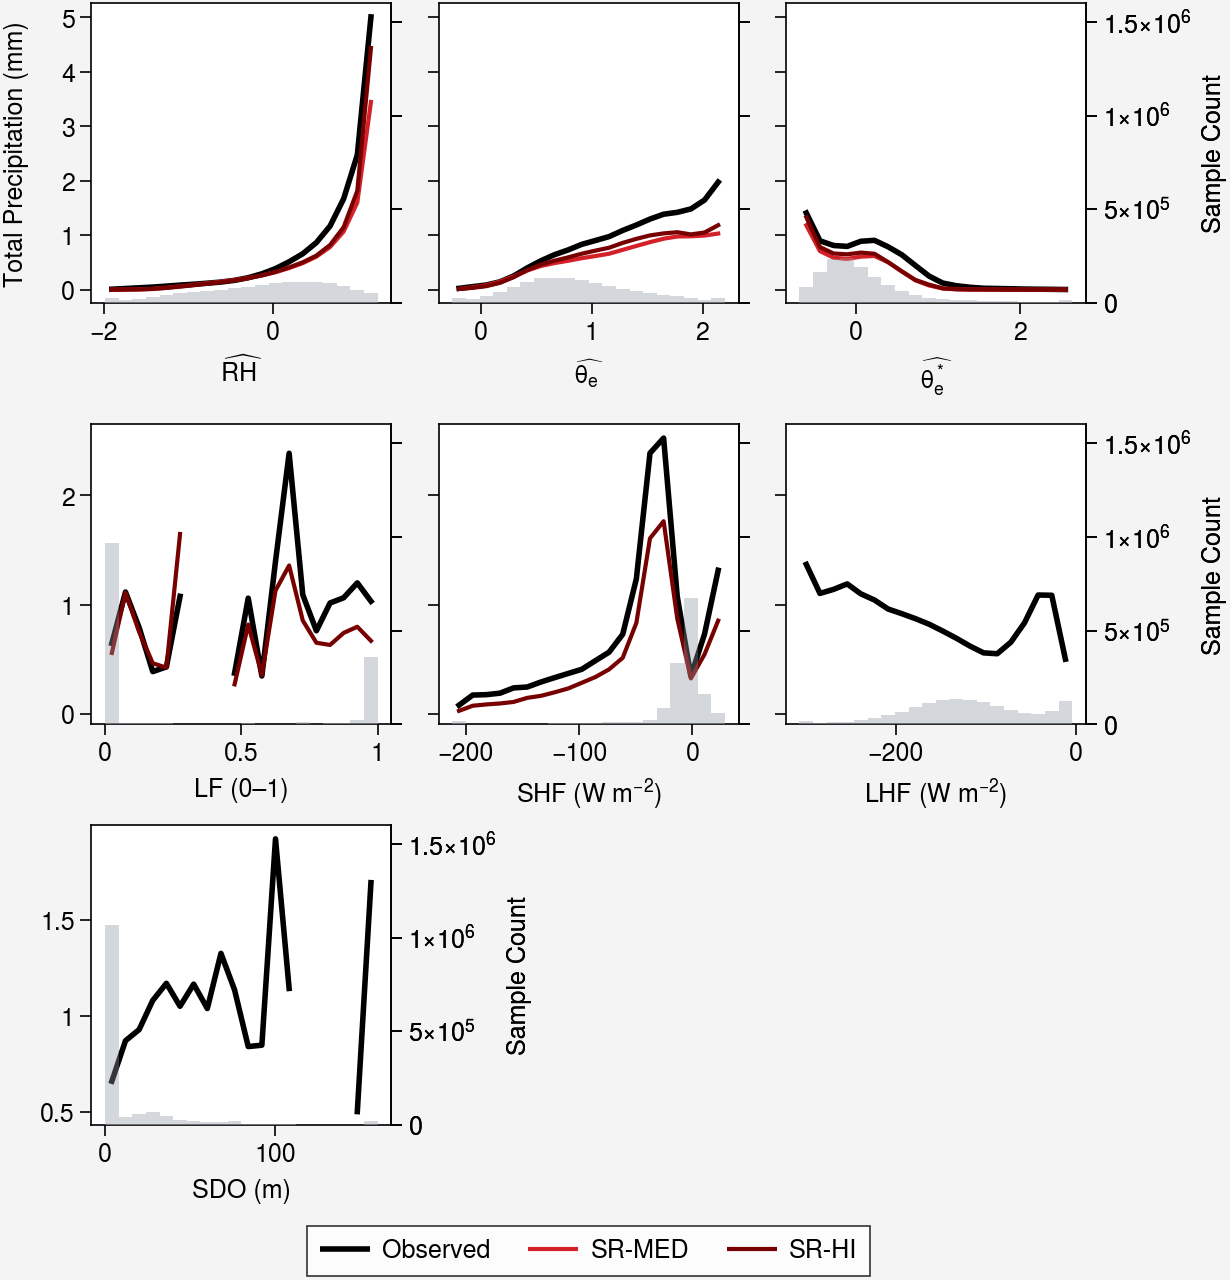

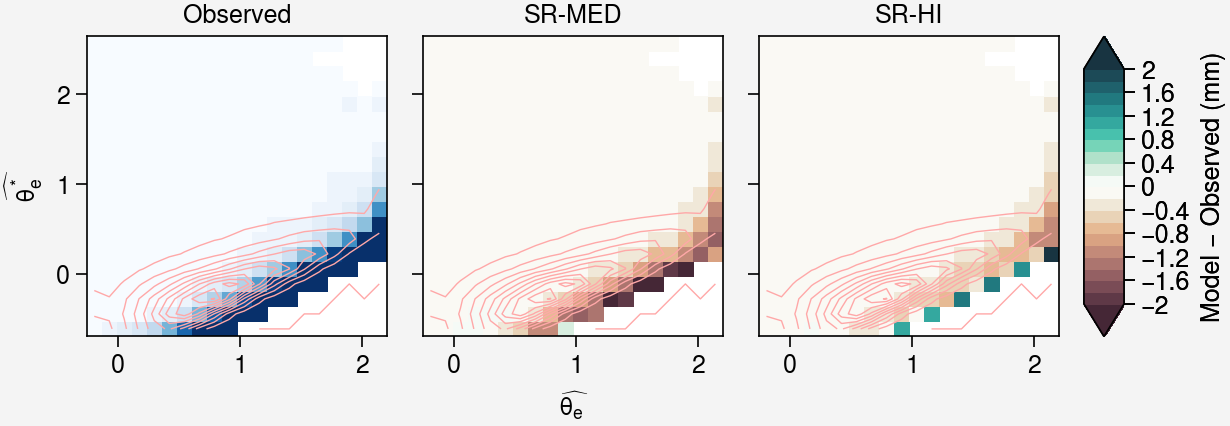

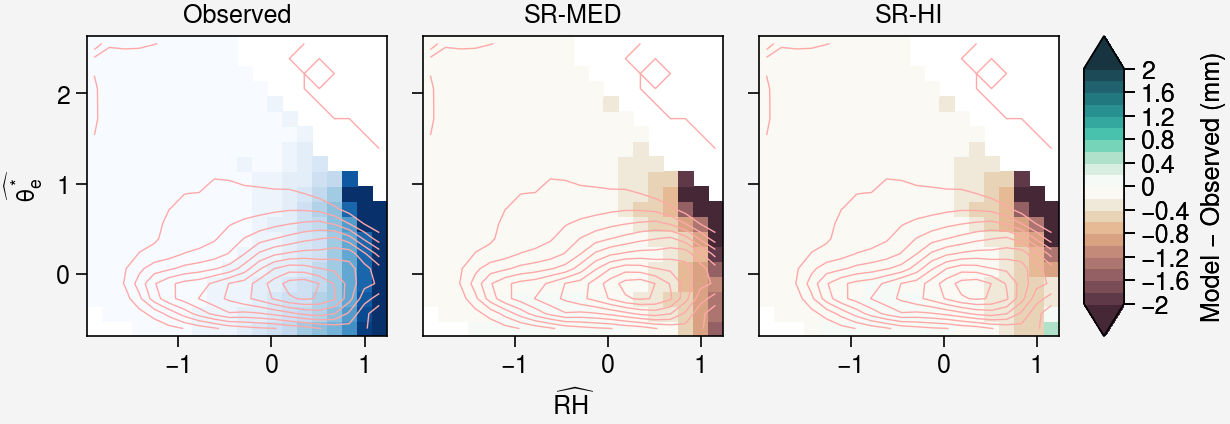

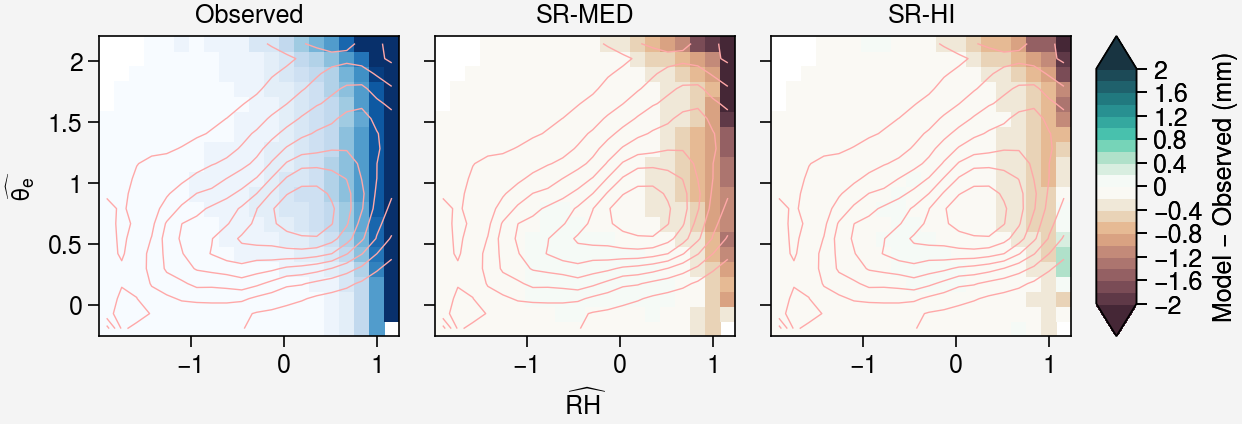

In [9]:
fig = plot1d([v for v in ['rh','thetae','thetaestar','lf','shf','lhf','sdo'] if v in FEATURES])
pplt.show()

for px,py in [('thetae','thetaestar'),('rh','thetaestar'),('rh','thetae')]:
    fig = plot2d(px,py)
    pplt.show()

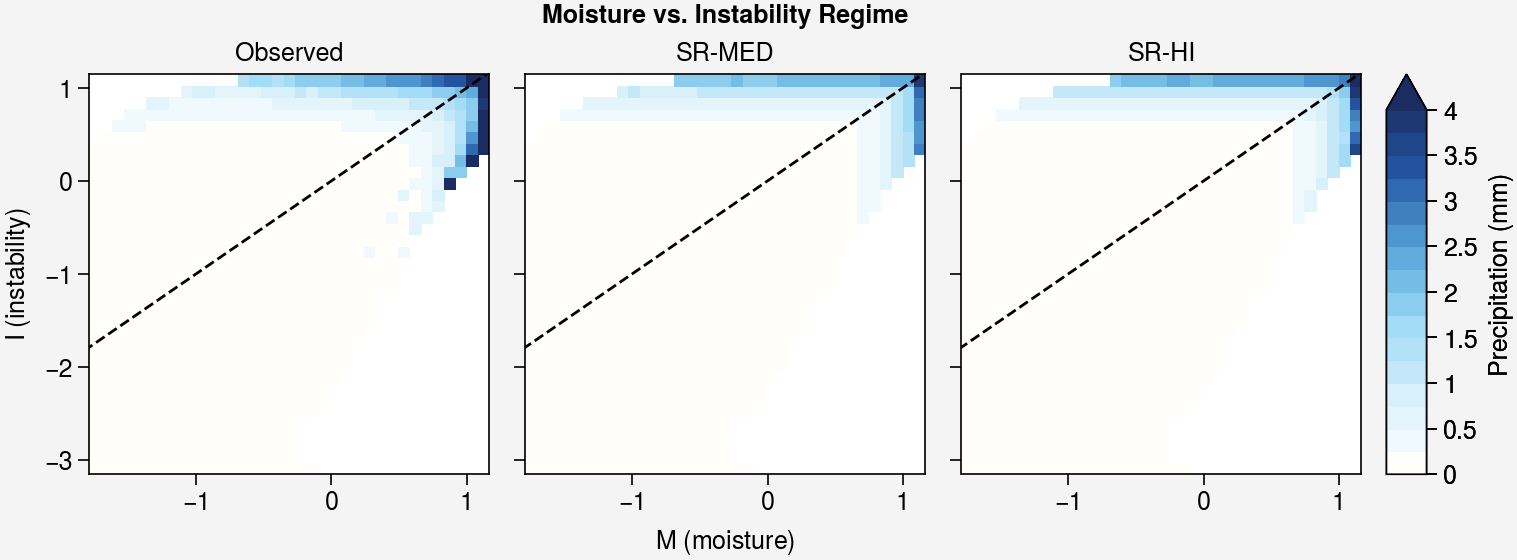

In [10]:
if 'sr_med' not in SR_REGISTRY:
    print('sr_med not in SR_REGISTRY — skipping M vs I plot')
else:
    c     = SR_REGISTRY['sr_med']['constants']
    obs   = obsflat[valid]
    names = [n for n in ORDER if n in MODELPRED]
    M = rhk[valid]
    I = thetaek[valid]-c['b']*thetaestark[valid]-c['c']

    Mlo,Mhi = float(np.percentile(M,2)),float(np.percentile(M,98))
    Ilo,Ihi = float(np.percentile(I,2)),float(np.percentile(I,98))
    axlo,axhi = min(Mlo,Ilo),max(Mhi,Ihi)

    panels = [('Observed',obs)]
    for name in names:
        panels.append((LABELS.get(name,name),MODELPRED[name][valid]))

    fig,axs = pplt.subplots(nrows=1,ncols=len(panels),refwidth=2,share=True)
    axsf = np.atleast_1d(axs).ravel()
    for i,(ax,(title,z)) in enumerate(zip(axsf,panels)):
        xc,yc,zbin,_ = bin_2d(M,I,z,nbins=35,minsamples=20,plo=2,phi=98)
        m = ax.pcolormesh(xc,yc,zbin.T,cmap='ColdHot_r',
                          cmap_kw={'left':0.5},vmin=0,vmax=4,
                          levels=18,extend='max')
        ax.plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
        ax.format(title=title,xlabel=r'$M$ (moisture)',
                  ylabel=r'$I$ (instability)' if i==0 else '',
                  grid=False,xlim=(Mlo,Mhi),ylim=(Ilo,Ihi))
    fig.colorbar(m,loc='r',label='Precipitation (mm)')
    fig.format(suptitle='Moisture vs. Instability Regime')
    pplt.show()

In [ ]:
names = [n for n in ORDER if n in MODELPRED]
obs   = obsflat[valid]

orogpanels = []
if sdo is not None:    orogpanels.append(('SDO (m)',               sdo,    sdomap))
if seflat is not None: orogpanels.append(('Surface Elevation (m)', seflat, semap))

ncols = len(orogpanels)
proj  = {i+1:'cyl' for i in range(ncols)}
fig,axs = pplt.subplots(nrows=2,ncols=ncols,proj=proj,refwidth=3,refheight=2,share=False)
for j,(oroglabel,orogflat,orogmap) in enumerate(orogpanels):
    m = axs[0,j].pcolormesh(lon,lat,orogmap,cmap='terrain',vmin=0,vmax=900,levels=30,extend='max')
    axs[0,j].format(title=oroglabel,latlabels='l' if j==0 else False,lonlabels='b',**KWMAP)
    orog  = orogflat[valid]
    lo,hi = np.percentile(orog,[2,98])
    edges = np.linspace(lo,hi,11); xc = 0.5*(edges[:-1]+edges[1:])
    idxs  = np.clip(np.digitize(orog,edges)-1,0,9)
    for name in names:
        pred = MODELPRED[name][valid]
        r2s  = [r2(obs[idxs==i],pred[idxs==i]) if (idxs==i).sum()>=500 else np.nan for i in range(10)]
        axs[1,j].plot(xc,r2s,color=COLORS[name],linewidth=1.5,marker='o',markersize=3,label=LABELS[name])
    axs[1,j].format(xlabel=oroglabel,ylabel=r'$R^2$' if j==0 else '',grid=False)
fig.colorbar(m,loc='b',col=(1,ncols),label='Elevation (m)')
axs[1,0].legend(loc='ll',ncols=1)
pplt.show()

In [ ]:
names = [n for n in ORDER if n in MODELPRED]
obs   = obsflat[valid]

def feat_corrs(residual):
    out = {}
    for vname,(arr,_) in FEATURES.items():
        x = arr[valid]
        m = np.isfinite(x)&np.isfinite(residual)
        if m.sum()>100:
            out[vname] = np.corrcoef(x[m],residual[m])[0,1]
    return out

all_corrs = {name:feat_corrs(obs-MODELPRED[name][valid]) for name in names}
all_feats = sorted(set().union(*[c.keys() for c in all_corrs.values()]))
max_abs   = {f:max(abs(all_corrs.get(n,{}).get(f,0)) for n in names) for f in all_feats}
ranked    = sorted(all_feats,key=lambda f:max_abs[f],reverse=True)

x     = np.arange(len(ranked))
width = 0.8/max(len(names),1)
fig,ax = pplt.subplots(refwidth=4,refheight=3)
for i,name in enumerate(names):
    vals   = [all_corrs.get(name,{}).get(f,0) for f in ranked]
    offset = (i-(len(names)-1)/2)*width
    ax.barh(x+offset,vals,height=width,
            color=COLORS[name],alpha=0.85-0.15*i,label=LABELS[name])
ax.format(yticks=x,
          yticklabels=[FEATURES[f][1] if f in FEATURES else f for f in ranked],
          xlabel='Pearson r (feature vs. residual)',
          title='Feature–Residual Correlation',grid=False,
          ylim=(-0.5,len(ranked)-0.5))
ax.axvline(0,color='gray',linewidth=0.7)
ax.legend(loc='lr',ncols=1,frame=False)
pplt.show()

In [ ]:
has_gap = 'nn_gauss' in MODELPRED and 'sr_hi' in MODELPRED
if has_gap:
    obs     = obsflat[valid]
    nn_pred = MODELPRED['nn_gauss'][valid]
    sr_pred = MODELPRED['sr_hi'][valid]

    gap_add   = nn_pred-sr_pred
    gap_log   = np.log1p(nn_pred)-np.log1p(sr_pred)
    truth_gap = obs-sr_pred

    gaps = {'NN − SR (add)':gap_add,'NN − SR (log)':gap_log,'Obs − SR (add)':truth_gap}

    results = {}
    for gname,gap in gaps.items():
        corrs = {}
        for vname,(arr,_) in FEATURES.items():
            x = arr[valid]
            m = np.isfinite(x)&np.isfinite(gap)
            if m.sum()>100:
                corrs[vname] = np.corrcoef(x[m],gap[m])[0,1]
        results[gname] = corrs

    ref_corrs = results['NN − SR (add)']
    ranked = sorted(ref_corrs.keys(),key=lambda f:abs(ref_corrs[f]),reverse=True)

    gap_names  = list(gaps.keys())
    gap_colors = ['#2355a1','#539ed4','#D42028']
    x     = np.arange(len(ranked))
    width = 0.8/len(gap_names)

    fig,ax = pplt.subplots(refwidth=4,refheight=3)
    for gi,gn in enumerate(gap_names):
        vals   = [results[gn].get(f,0) for f in ranked]
        offset = (gi-(len(gap_names)-1)/2)*width
        ax.barh(x+offset,vals,height=width,color=gap_colors[gi],label=gn)
    ax.format(yticks=x,
              yticklabels=[FEATURES[f][1] if f in FEATURES else f for f in ranked],
              xlabel='Pearson r',
              title='Feature Correlation with Distillation Gap',grid=False,
              ylim=(-0.5,len(ranked)-0.5))
    ax.axvline(0,color='gray',linewidth=0.7)
    ax.legend(loc='lr',ncols=1,frame=False)
    pplt.show()

    top_feats = ranked[:6]
    ncols_g = min(3,len(top_feats)); nrows_g = -(-len(top_feats)//ncols_g)
    fig,axs = pplt.subplots(nrows=nrows_g,ncols=ncols_g,refwidth=1.8,
                             refheight=1.5,sharex=False,sharey=True)
    axsf = np.atleast_1d(axs).ravel()
    for i,(ax,f) in enumerate(zip(axsf,top_feats)):
        ax.axhline(0,color='gray',linewidth=0.7,linestyle='--')
        xc,means,_ = bin_1d(FEATURES[f][0][valid],gap_add)
        ax.plot(xc,means,color='#2355a1',linewidth=1.5)
        xc_l,means_l,_ = bin_1d(FEATURES[f][0][valid],gap_log)
        ax.plot(xc_l,means_l,color='#539ed4',linewidth=1.5,linestyle='--')
        ax.format(grid=False,xlabel=FEATURES[f][1] if f in FEATURES else f,
                  ylabel='Gap' if i%ncols_g==0 else '')
    for ax in axsf[len(top_feats):]: ax.set_visible(False)
    handles = [Line2D([],[],color='#2355a1',linewidth=1.5,label='Additive'),
               Line2D([],[],color='#539ed4',linewidth=1.5,linestyle='--',label='Log-space')]
    fig.legend(handles,loc='b',ncols=2)
    fig.format(suptitle='Distillation Gap vs. Features')
    pplt.show()
else:
    print('Need both nn_gauss and sr_hi for distillation gap analysis')